In [1]:
# PRIMARY GOAL - can an OkCupid's user astrological sign can be predicted using other variables from their profiles?

In [2]:
## General libraries
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = [6, 6]
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load data into pandas DataFrame and view first 5 rows
profiles = pd.read_csv('profiles.csv', encoding='utf-8')
profiles.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [4]:
# View size of df
profiles.shape
# enough data for machiene learning

(59946, 31)

In [5]:
# View columns and datatypes of columns
profiles.dtypes

age              int64
body_type       object
diet            object
drinks          object
drugs           object
education       object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
orientation     object
pets            object
religion        object
sex             object
sign            object
smokes          object
speaks          object
status          object
dtype: object

In [6]:
# Find number of unique zodiac signs and values (should only be 12)
print("Number of listed zodiac signs: {}".format(profiles.sign.nunique()))

Number of listed zodiac signs: 48


In [7]:
# Find why there are so many listed zodiac signs
print("Listed zodiac signs: \n{}".format(profiles.sign.value_counts()))

Listed zodiac signs: 
gemini and it&rsquo;s fun to think about         1782
scorpio and it&rsquo;s fun to think about        1772
leo and it&rsquo;s fun to think about            1692
libra and it&rsquo;s fun to think about          1649
taurus and it&rsquo;s fun to think about         1640
cancer and it&rsquo;s fun to think about         1597
pisces and it&rsquo;s fun to think about         1592
sagittarius and it&rsquo;s fun to think about    1583
virgo and it&rsquo;s fun to think about          1574
aries and it&rsquo;s fun to think about          1573
aquarius and it&rsquo;s fun to think about       1503
virgo but it doesn&rsquo;t matter                1497
leo but it doesn&rsquo;t matter                  1457
cancer but it doesn&rsquo;t matter               1454
gemini but it doesn&rsquo;t matter               1453
taurus but it doesn&rsquo;t matter               1450
libra but it doesn&rsquo;t matter                1408
aquarius but it doesn&rsquo;t matter             1408
capric

In [8]:
# Create a new column containing only the first word of the sign column
profiles['signCleaned'] = profiles.sign.str.split().str[0]
# splits column data into individual strings and selects ony the first one

In [9]:
print("Number of cleaned zodiac signs: {}".format(profiles.signCleaned.nunique()))

Number of cleaned zodiac signs: 12


In [10]:
print("Listed cleaned zodiac signs: \n{}".format(profiles.signCleaned.value_counts()))

Listed cleaned zodiac signs: 
leo            4374
gemini         4310
libra          4207
cancer         4206
virgo          4141
taurus         4140
scorpio        4134
aries          3989
pisces         3946
sagittarius    3942
aquarius       3928
capricorn      3573
Name: signCleaned, dtype: int64


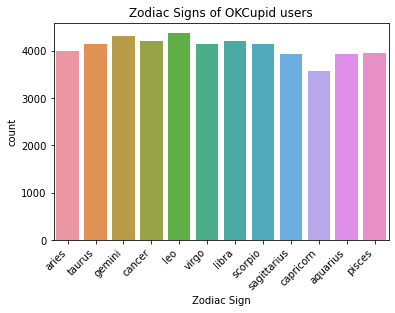

In [11]:
# Show histogram showing zodiac sign
zodiac_order = ['aries', 'taurus', 'gemini', 'cancer', 'leo', 'virgo', 'libra', 'scorpio', 'sagittarius', 'capricorn', 'aquarius', 'pisces']
profiles['signCleaned'] = pd.Categorical(profiles['signCleaned'], categories=zodiac_order, ordered=True)

sns.countplot(data=profiles, x='signCleaned')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Zodiac Sign')
plt.title("Zodiac Signs of OKCupid users")
plt.show()

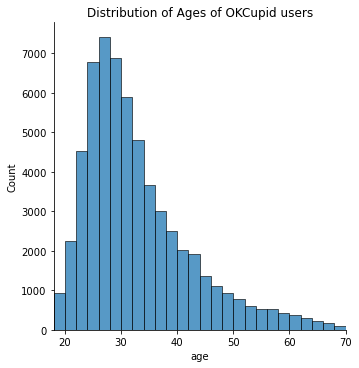

In [12]:
# Show distribution of age in the data in a histogram (becuase age is a continuous variable)
sns.displot(profiles, x='age', kind='hist', binwidth = 2)
# limit the x-axis range to exclude outliers
plt.xlim(18, 70)
plt.title('Distribution of Ages of OKCupid users')
plt.show()

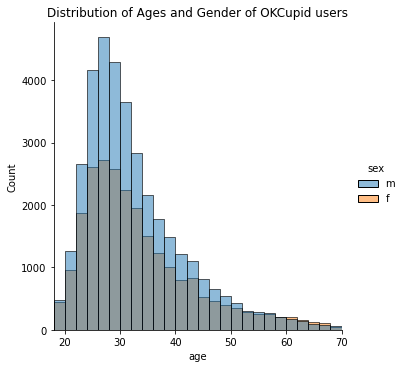

In [13]:
# show same plot but include gender
sns.displot(profiles, x='age', hue='sex', kind='hist', binwidth = 2)
# limit the x-axis range to exclude outliers
plt.xlim(18, 70)
plt.title('Distribution of Ages and Gender of OKCupid users')
plt.show()

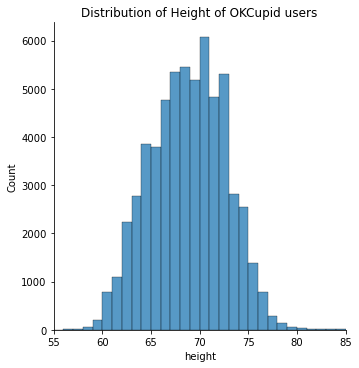

In [14]:
# Show distribution of age in the data in a histogram (becuase age is a continuous variable)
sns.displot(profiles, x='height', kind='hist', binwidth=1)
# limit the x-axis range to exclude outliers
plt.xlim(55, 85)
plt.title('Distribution of Height of OKCupid users')
plt.show()

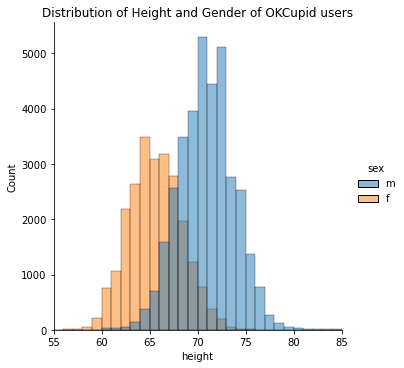

In [15]:
# Show distribution of age and gender the data in a histogram (becuase height is a continuous variable)
sns.displot(profiles, x='height', hue='sex', kind='hist', binwidth=1)
# limit the x-axis range to exclude outliers
plt.xlim(55, 85)
plt.title('Distribution of Height and Gender of OKCupid users')
plt.show()

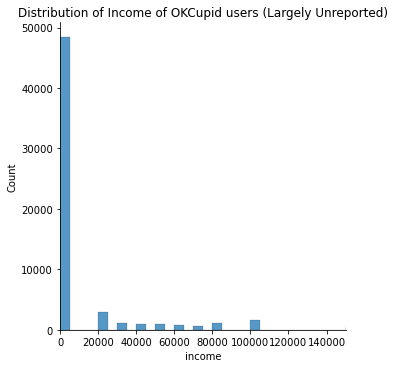

In [16]:
# Show distribution of income in a histogram (because income is a continuous variable)
sns.displot(profiles, x='income', kind='hist', binwidth=5000)
# limit the x-axis range to exclude outliers
plt.xlim(0, 150000)
plt.title('Distribution of Income of OKCupid users (Largely Unreported)')
plt.show()
# The data is skewed becuase the large majority of OKCupid users
# do not include thier income

In [17]:
# Moving on to Discrete Variables - use sns.countplot instead of sns.displot

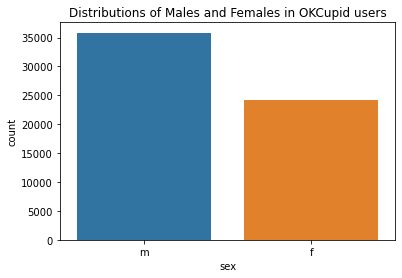

In [18]:
# Show histogram of gender
sns.countplot(data=profiles, x='sex')
plt.title('Distributions of Males and Females in OKCupid users')
plt.show()

In [19]:
# View body types
print(profiles.body_type.value_counts())

# Modify body type column from a discrete variable to an ordered categorical variable
# Based on relative size/appeal
bodytype_order = ['skinny', 'thin', 'fit', 'athletic', 'jacked', 'average', 'curvy', 'a little extra', 'full figured', 'overweight', 'used up', 'rather not say']
profiles['body_type'] = pd.Categorical(profiles['body_type'], categories=bodytype_order, ordered=True)

average           14652
fit               12711
athletic          11819
thin               4711
curvy              3924
a little extra     2629
skinny             1777
full figured       1009
overweight          444
jacked              421
used up             355
rather not say      198
Name: body_type, dtype: int64


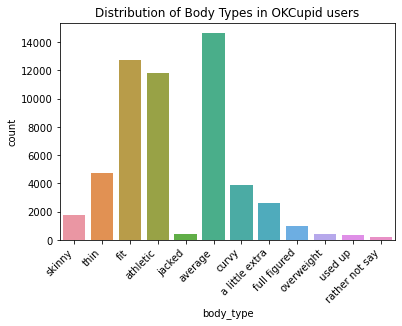

In [20]:
# Show histogram of body type
sns.countplot(data=profiles, x='body_type')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Body Types in OKCupid users')
plt.show()

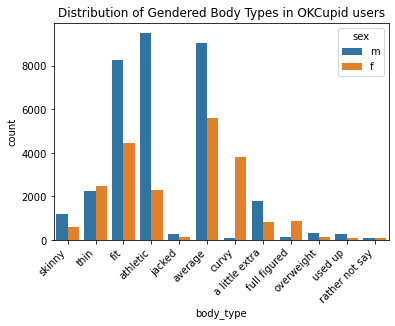

In [21]:
# Show histogram of body type by gender
sns.countplot(data=profiles, x='body_type', hue='sex')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Gendered Body Types in OKCupid users')
plt.show()

In [22]:
# View diets
print(profiles.diet.value_counts())

# Modify diet column from a discrete variable to an ordered categorical variable
# Based on limitability of options
diet_order = ['anything', 'mostly anything', 'strictly anything', 'mostly other', 'other', 'strictly other', 'mostly halal', 'halal', 'strictly halal', 'mostly vegetarian', 'vegetarian', 'strictly vegetarian', 'mostly vegan', 'vegan', 'strictly vegan', 'mostly kosher', 'kosher', 'strictly kosher']
profiles['diet'] = pd.Categorical(profiles['diet'], categories=diet_order, ordered=True)

mostly anything        16585
anything                6183
strictly anything       5113
mostly vegetarian       3444
mostly other            1007
strictly vegetarian      875
vegetarian               667
strictly other           452
mostly vegan             338
other                    331
strictly vegan           228
vegan                    136
mostly kosher             86
mostly halal              48
strictly halal            18
strictly kosher           18
halal                     11
kosher                    11
Name: diet, dtype: int64


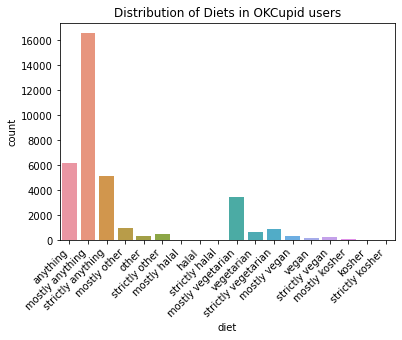

In [23]:
# Show histogram of diet
sns.countplot(data=profiles, x='diet')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Diets in OKCupid users')
plt.show()

In [24]:
# View drinking habits
print(profiles.drinks.value_counts())

# Modify drink column from a discrete variable to an ordered categorical variable
# Based on frequency of drinking
drinkFreq_order = ['not at all', 'rarely', 'socially', 'often', 'very often', 'desperately']
profiles['drinks'] = pd.Categorical(profiles['drinks'], categories=drinkFreq_order, ordered=True)

socially       41780
rarely          5957
often           5164
not at all      3267
very often       471
desperately      322
Name: drinks, dtype: int64


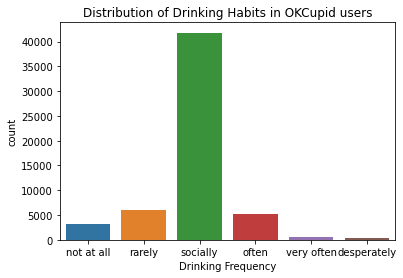

In [25]:
# Show histogram of drinking habits
sns.countplot(data=profiles, x='drinks')
plt.xlabel('Drinking Frequency')
plt.title('Distribution of Drinking Habits in OKCupid users')
plt.show()

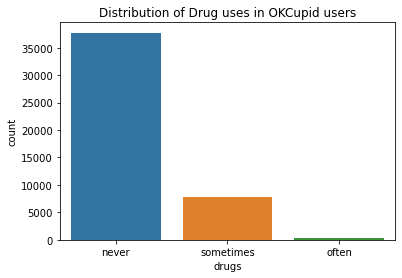

In [26]:
# Show histogram of drug use
sns.countplot(data=profiles, x='drugs')
plt.title('Distribution of Drug uses in OKCupid users')
plt.show()

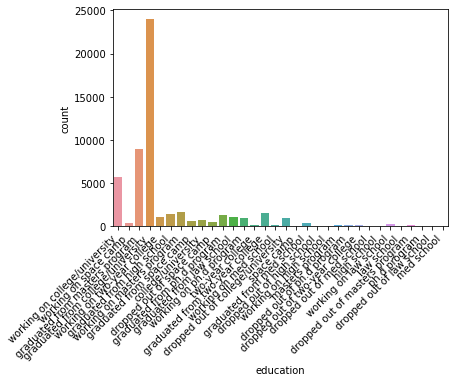

In [27]:
# Show histogram of education level
sns.countplot(data=profiles, x='education')
plt.xticks(rotation=45, ha='right')
plt.show()

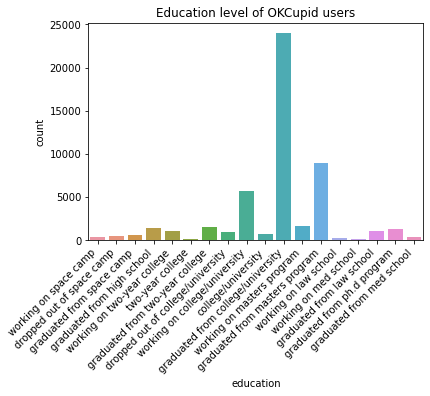

In [28]:
# Show a better histogram only showing x features that are significant
# and add order to education
education_order = ['working on space camp', 'dropped out of space camp', 'graduated from space camp', 'graduated from high school', 'working on two-year college', 'two-year college', 'graduated from two-year college', 'dropped out of college/university', 'working on college/university', 'college/university', 'graduated from college/university', 'working on masters program', 'graduated from masters program', 'working on law school', 'working on med school', 'graduated from law school', 'graduated from ph.d program', 'graduated from med school']
profiles['education'] = pd.Categorical(profiles['education'], categories=education_order, ordered=True)

lowest_sig_count = profiles['education'].value_counts().get('working on med school', 0)

value_counts = profiles['education'].value_counts()
cats_to_keep = value_counts[value_counts >= lowest_sig_count].index

filtered_profiles = profiles[profiles['education'].isin(cats_to_keep)]

sns.countplot(data=filtered_profiles, x='education')
plt.xticks(rotation=45, ha='right')
plt.title('Education level of OKCupid users')
plt.show()

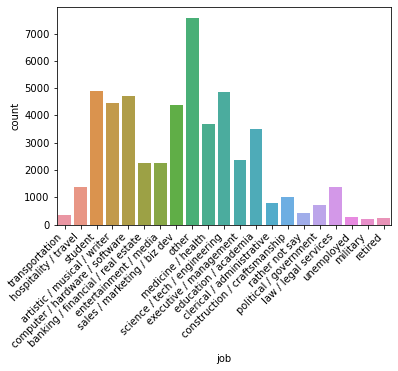

In [29]:
# Show histogram showing jobs
sns.countplot(data=profiles, x='job')
plt.xticks(rotation=45, ha='right')
plt.show()

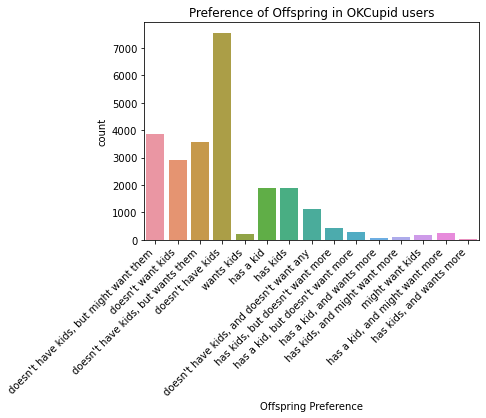

In [30]:
# Show histogram showing offspring

# fix format so that the apostrophe doesn't look like &rsquo;
profiles['offspring'] = profiles['offspring'].str.replace('&rsquo;', "'").str.replace('&rsquo;', "'")

sns.countplot(data=profiles, x='offspring')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Offspring Preference')
plt.title('Preference of Offspring in OKCupid users')
plt.show()

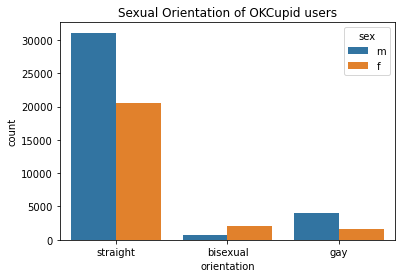

In [31]:
# Show histogram showing sexual orientation
sns.countplot(data=profiles, x='orientation', hue='sex')
plt.title("Sexual Orientation of OKCupid users")
plt.show()

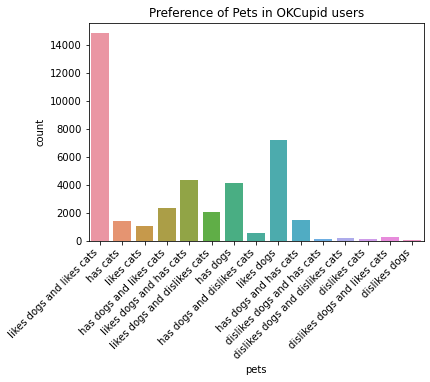

In [32]:
# Show histogram showing pet preference
sns.countplot(data=profiles, x='pets')
plt.xticks(rotation=45, ha='right')
plt.title("Preference of Pets in OKCupid users")
plt.show()

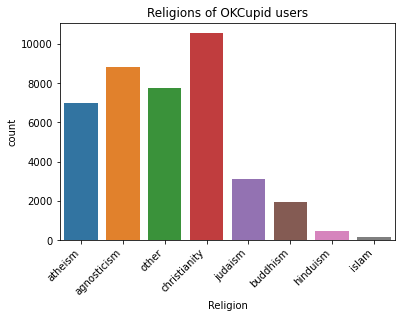

In [33]:
# Show histogram showing religion
# clean religion feauture similar to diet feature (split string and get first word)
profiles['religionCleaned'] = profiles.religion.str.split().str.get(0)
# change catholicism to christianity
profiles['religionCleaned'] = profiles['religionCleaned'].replace('catholicism', 'christianity')

religion_order = ['atheism', 'agnosticism', 'other', 'christianity', 'judaism', 'buddhism', 'hinduism',  'islam']
profiles['religionCleaned'] = pd.Categorical(profiles['religionCleaned'], categories=religion_order, ordered=True)

sns.countplot(data=profiles, x='religionCleaned')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Religion')
plt.title("Religions of OKCupid users")
plt.show()

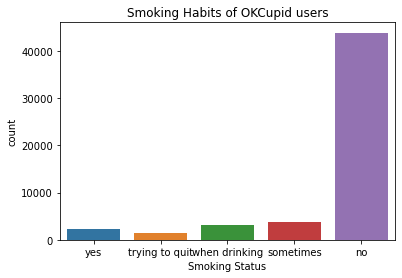

In [34]:
# Show histogram for smoking
smokes_order = ['yes', 'trying to quit', 'when drinking', 'sometimes', 'no']
profiles['smokes'] = pd.Categorical(profiles['smokes'], categories=smokes_order, ordered=True)

sns.countplot(data=profiles, x='smokes')
plt.title("Smoking Habits of OKCupid users")
plt.xlabel('Smoking Status')
plt.show()

In [35]:
# DATA PREPARATION FOR ML
print("Number of missing vaues in columns: ")
profiles.isnull().sum()

Number of missing vaues in columns: 


age                    0
body_type           5296
diet               24395
drinks              2985
drugs              14080
education           8634
essay0              5488
essay1              7572
essay2              9638
essay3             11476
essay4             10537
essay5             10850
essay6             13771
essay7             12451
essay8             19225
essay9             12603
ethnicity           5680
height                 3
income                 0
job                 8198
last_online            0
location               0
offspring          35561
orientation            0
pets               19921
religion           20226
sex                    0
sign               11056
smokes              5512
speaks                50
status                 0
signCleaned        11056
religionCleaned    20226
dtype: int64

In [36]:
# Choose columns for ML including predictor label at the end
cols = ['body_type', 'diet', 'drinks', 'income',  'job', 'orientation', 'pets', 'religionCleaned',
       'sex', 'signCleaned']
df = profiles[cols].dropna()
df.shape

(16259, 10)

In [37]:
# create dummy vaiables for catergorical variables. Omit the predictor label
for col in cols[:-1]:
    df = pd.get_dummies(df, columns=[col], prefix = [col])
df.head()

,signCleaned,body_type_skinny,body_type_thin,body_type_fit,body_type_athletic,body_type_jacked,body_type_average,body_type_curvy,body_type_a little extra,body_type_full figured,...,religionCleaned_atheism,religionCleaned_agnosticism,religionCleaned_other,religionCleaned_christianity,religionCleaned_judaism,religionCleaned_buddhism,religionCleaned_hinduism,religionCleaned_islam,sex_f,sex_m
0,gemini,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
1,cancer,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
5,taurus,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
7,sagittarius,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
9,cancer,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [38]:
# split data into train and test sets
X = df.iloc[:, 1:len(df.columns)]
y = df.iloc[:, 0:1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# turn labels into 1D arrays
y_train = y_train.to_numpy().ravel()
y_test =  y_test.to_numpy().ravel()

In [39]:
# import models
import sys
print(sys.executable)
print(sys.version)

!{sys.executable} -m pip install --upgrade scikit-learn


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

/opt/anaconda3/bin/python
3.8.5 (default, Sep  4 2020, 02:22:02) 
[Clang 10.0.0 ]
Requirement already up-to-date: scikit-learn in /opt/anaconda3/lib/python3.8/site-packages (1.3.2)


In [41]:
# create a and fit logistic regression model
lr_model = LogisticRegression(multi_class="multinomial")
lr_model.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

In [43]:
lr_predictions = lr_model.predict(X_train)

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_train, lr_predictions))

# the f1 score is only around 0.12
# a random guess would be around 0.08 (1/12)
# this model performs poorly

              precision    recall  f1-score   support

    aquarius       0.11      0.03      0.05      1001
       aries       0.11      0.12      0.12      1061
      cancer       0.13      0.20      0.16      1141
   capricorn       0.13      0.05      0.08       938
      gemini       0.12      0.17      0.14      1201
         leo       0.13      0.18      0.15      1190
       libra       0.12      0.12      0.12      1094
      pisces       0.12      0.10      0.11      1044
 sagittarius       0.13      0.11      0.12      1053
     scorpio       0.12      0.07      0.09      1068
      taurus       0.11      0.11      0.11      1090
       virgo       0.13      0.19      0.15      1126

    accuracy                           0.12     13007
   macro avg       0.12      0.12      0.12     13007
weighted avg       0.12      0.12      0.12     13007



In [46]:
# Create and fit a K-nearest-neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [47]:
knn_predictions = knn_model.predict(X_train)

In [50]:
print(classification_report(y_train, knn_predictions))
# weighted average is 0.33 which is significantly better than randomly guessing

              precision    recall  f1-score   support

    aquarius       0.25      0.65      0.36      1001
       aries       0.27      0.54      0.36      1061
      cancer       0.32      0.44      0.37      1141
   capricorn       0.34      0.35      0.34       938
      gemini       0.37      0.32      0.34      1201
         leo       0.41      0.29      0.34      1190
       libra       0.42      0.27      0.33      1094
      pisces       0.40      0.27      0.32      1044
 sagittarius       0.42      0.22      0.29      1053
     scorpio       0.40      0.23      0.30      1068
      taurus       0.42      0.23      0.30      1090
       virgo       0.44      0.27      0.33      1126

    accuracy                           0.34     13007
   macro avg       0.37      0.34      0.33     13007
weighted avg       0.37      0.34      0.33     13007



In [52]:
# create a and fit decision tree model
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [53]:
tree_predictions = tree_model.predict(X_train)

In [54]:
print(classification_report(y_train, tree_predictions))
# Model shows 88% accuracy!
# however is it likely overfit to the data (becuase it is a decision tree)

              precision    recall  f1-score   support

    aquarius       0.80      0.97      0.88      1001
       aries       0.79      0.95      0.86      1061
      cancer       0.83      0.94      0.88      1141
   capricorn       0.85      0.91      0.88       938
      gemini       0.85      0.90      0.88      1201
         leo       0.89      0.88      0.89      1190
       libra       0.90      0.87      0.89      1094
      pisces       0.91      0.85      0.88      1044
 sagittarius       0.92      0.83      0.87      1053
     scorpio       0.95      0.84      0.89      1068
      taurus       0.97      0.85      0.90      1090
       virgo       0.97      0.80      0.88      1126

    accuracy                           0.88     13007
   macro avg       0.89      0.88      0.88     13007
weighted avg       0.89      0.88      0.88     13007



In [62]:
from sklearn.metrics import confusion_matrix
tree_cm = confusion_matrix(y_train, tree_predictions)
tree_labels = tree_model.classes_

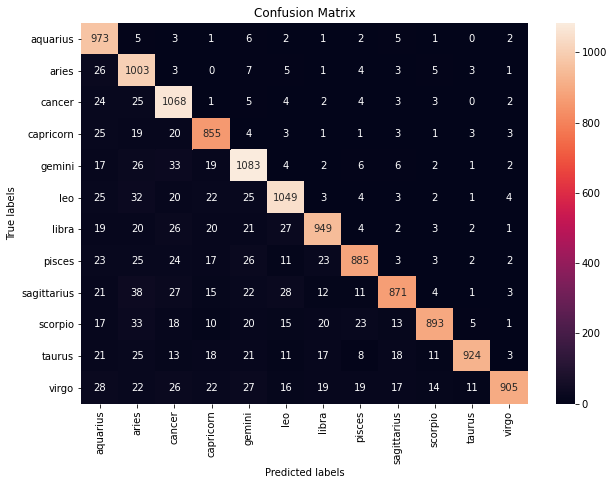

In [63]:
plt.figure(figsize=(10,7))

ax= plt.subplot()
sns.heatmap(tree_cm, annot=True, ax = ax,fmt="d");

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix');
ax.yaxis.set_tick_params(rotation=360)
ax.xaxis.set_tick_params(rotation=90)

ax.xaxis.set_ticklabels(tree_labels); 
ax.yaxis.set_ticklabels(tree_labels);

In [66]:
tree_model.get_depth()
# a depth of 66 is very high (highly over fits data)

66

In [69]:
# use a five-fold cross validation to prevent overfitting the data
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=0)
results = cross_val_score(tree_model, X_train, y_train, cv=kfold, scoring='accuracy')

print(results)
print("Baseline: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

[0.07878555 0.08647194 0.08573626 0.08496732 0.08150711]
Baseline: 8.35% (0.29%)


In [70]:
# when the model is adjusted to prevent overfitting, it performs very poorly (8.35%)
# adjust the decision tree so the max depth is 20
tree_model20 = DecisionTreeClassifier(max_depth = 20).fit(X_train, y_train) 
tree_predictions20 = tree_model20.predict(X_train) 

In [73]:
print(classification_report(y_train, tree_predictions20))

              precision    recall  f1-score   support

    aquarius       0.59      0.29      0.39      1001
       aries       0.30      0.38      0.34      1061
      cancer       0.59      0.29      0.39      1141
   capricorn       0.73      0.28      0.41       938
      gemini       0.20      0.49      0.28      1201
         leo       0.37      0.39      0.38      1190
       libra       0.58      0.30      0.39      1094
      pisces       0.30      0.32      0.31      1044
 sagittarius       0.52      0.26      0.35      1053
     scorpio       0.69      0.26      0.37      1068
      taurus       0.23      0.34      0.27      1090
       virgo       0.25      0.40      0.31      1126

    accuracy                           0.34     13007
   macro avg       0.45      0.33      0.35     13007
weighted avg       0.44      0.34      0.35     13007



In [76]:
# the accuracy is 0.35 with a depth of 20, but lets verify with cross validation
results20 = cross_val_score(tree_model20, X_train, y_train, cv=kfold, scoring='accuracy')

print(results20)
print("Baseline: %.2f%% (%.2f%%)" % (results20.mean()*100, results.std()*100))

[0.09377402 0.08724058 0.08804306 0.08804306 0.08535179]
Baseline: 8.85% (0.29%)


In [77]:
# ALL ML ALGORITHMS HAD VERY LOW SCORES
# CONCLUSION - ML WAS UNABLE TO PREDICT ZODIAC SIGN BASED ON GIVEN INPUTS
#   NOT ANY BETTER THAN RANDOM GUESSING